In [55]:
!pip install duckdb


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [56]:
#original Dataset Count 
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
duckdb.query("SELECT COUNT(*) FROM 'US_Accidents_March23.csv'").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      7728394 │
└──────────────┘



In [57]:
#printing the First 10 rows
con = duckdb.connect()
df = con.execute("""
    SELECT *
    FROM 'US_Accidents_March23.csv'
    LIMIT 10
""").fetchdf()

print(df)

     ID   Source  Severity          Start_Time            End_Time  Start_Lat  \
0   A-1  Source2         3 2016-02-08 05:46:00 2016-02-08 11:00:00  39.865147   
1   A-2  Source2         2 2016-02-08 06:07:59 2016-02-08 06:37:59  39.928059   
2   A-3  Source2         2 2016-02-08 06:49:27 2016-02-08 07:19:27  39.063148   
3   A-4  Source2         3 2016-02-08 07:23:34 2016-02-08 07:53:34  39.747753   
4   A-5  Source2         2 2016-02-08 07:39:07 2016-02-08 08:09:07  39.627781   
5   A-6  Source2         3 2016-02-08 07:44:26 2016-02-08 08:14:26  40.100590   
6   A-7  Source2         2 2016-02-08 07:59:35 2016-02-08 08:29:35  39.758274   
7   A-8  Source2         3 2016-02-08 07:59:58 2016-02-08 08:29:58  39.770382   
8   A-9  Source2         2 2016-02-08 08:00:40 2016-02-08 08:30:40  39.778061   
9  A-10  Source2         3 2016-02-08 08:10:04 2016-02-08 08:40:04  40.100590   

   Start_Lng End_Lat End_Lng  Distance(mi)  \
0 -84.058723    None    None          0.01   
1 -82.831184    

In [58]:
#cutting down datset to the 1500000
con = duckdb.connect()

con.execute("""
CREATE TABLE sampled_data AS
SELECT *
FROM 'US_Accidents_March23.csv'
USING SAMPLE 1500000 ROWS;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
#counting the row 
rows = con.execute("""
    SELECT COUNT(*) 
    FROM sampled_data
""").fetchone()[0]

print("Row count:", rows)


Row count: 1500000


In [6]:
con.execute("""
CREATE OR REPLACE TABLE sampled_data AS
SELECT *
FROM 'US_Accidents_March23.csv'
USING SAMPLE 1500000 ROWS;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [8]:
con = duckdb.connect("accidents.duckdb")  # ← persistent DB file

con.execute("""
CREATE OR REPLACE TABLE sampled_data AS
SELECT *
FROM 'US_Accidents_March23.csv'
USING SAMPLE 1500000 ROWS;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
import pandas as pd

pd.set_option("display.max_columns", None)

con = duckdb.connect("accidents.duckdb")

df = con.execute("""
    SELECT *
    FROM sampled_data
    LIMIT 10
""").fetchdf()

print(df)

          ID   Source  Severity          Start_Time            End_Time  \
0  A-2993447  Source2         2 2018-02-06 06:47:16 2018-02-06 07:17:00   
1  A-4199649  Source1         2 2022-11-09 08:09:49 2022-11-09 09:24:59   
2  A-5975872  Source1         2 2021-12-23 22:52:00 2021-12-24 03:32:09   
3  A-5193522  Source1         2 2022-04-02 12:18:00 2022-04-02 12:55:30   
4  A-4188386  Source1         2 2022-03-17 21:08:23 2022-03-17 22:26:24   
5  A-7275751  Source1         2 2020-02-25 06:45:00 2020-02-25 07:16:34   
6  A-6796048  Source1         2 2020-10-06 08:49:00 2020-10-06 10:35:52   
7  A-3172269  Source2         4 2017-11-07 06:29:23 2017-11-07 06:56:40   
8  A-4614249  Source1         2 2022-04-05 08:55:00 2022-04-05 10:16:00   
9  A-7463704  Source1         2 2019-01-15 06:41:33 2019-01-15 07:11:10   

   Start_Lat   Start_Lng            End_Lat             End_Lng  Distance(mi)  \
0  44.919666  -93.274490               None                None         0.000   
1  41.411074

In [10]:
rows = con.execute("""
    SELECT COUNT(*) 
    FROM sampled_data
""").fetchone()[0]

print("Row count:", rows)

Row count: 1500000


In [11]:
#Dataset Overview 
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     10 non-null     object        
 1   Source                 10 non-null     object        
 2   Severity               10 non-null     int64         
 3   Start_Time             10 non-null     datetime64[us]
 4   End_Time               10 non-null     datetime64[us]
 5   Start_Lat              10 non-null     float64       
 6   Start_Lng              10 non-null     float64       
 7   End_Lat                8 non-null      object        
 8   End_Lng                8 non-null      object        
 9   Distance(mi)           10 non-null     float64       
 10  Description            10 non-null     object        
 11  Street                 10 non-null     object        
 12  City                   10 non-null     object        
 13  County  

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,10.000000,10,10,10.000000,10.000000,10.000000,10,10.000000,8.000000,10.000000,10.000000,10.000000,10.00000,7.0
mean,2.200000,2020-09-29 15:41:32.400000,2020-09-29 16:59:13.800000,37.665463,-98.850371,0.413000,2020-09-29 15:43:00,46.070000,41.525000,76.000000,29.853000,8.900000,5.43000,0.0
min,2.000000,2017-11-07 06:29:23,2017-11-07 06:56:40,31.866333,-124.032299,0.000000,2017-11-07 06:53:00,-5.100000,-15.800000,41.000000,29.000000,2.000000,0.00000,0.0
25%,2.000000,2019-04-26 18:42:24.750000,2019-04-26 19:12:31,33.953479,-118.263764,0.034000,2019-04-26 18:51:30,46.250000,41.750000,75.500000,29.695000,10.000000,0.87500,0.0
50%,2.000000,2021-05-16 03:50:30,2021-05-16 07:04:00.500000,37.789028,-97.788196,0.172000,2021-05-16 03:53:00,48.450000,45.000000,81.000000,29.970000,10.000000,4.80000,0.0
75%,2.000000,2022-03-29 14:30:35.750000,2022-03-29 15:18:13.500000,40.731441,-80.342451,0.461750,2022-03-29 14:14:15,55.175000,53.750000,86.750000,30.017500,10.000000,6.00000,0.0
max,4.000000,2022-11-09 08:09:49,2022-11-09 09:24:59,44.919666,-75.152279,1.896000,2022-11-09 07:53:00,68.000000,68.000000,97.000000,30.490000,10.000000,20.00000,0.0
std,0.632456,NaN,NaN,4.225204,19.709815,0.589466,NaN,19.335003,24.982951,18.196459,0.399139,2.601282,5.96472,0.0


In [ ]:
# Feature Engineering:
# This section derives new analytical features from raw data to enhance interpretability and support OLAP analysis.
# Duration is calculated in minutes to measure accident impact on traffic.
# TimeOfDay categorizes accident start time into Morning, Afternoon, Evening, and Night
# to simplify temporal pattern analysis.
# Temp_Category groups continuous temperature values into Cold, Mild, and Hot
# to enable meaningful aggregation and business-level comparisons.

In [12]:
import pandas as pd
import numpy as np

# Ensure datetime format
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')

# --------------------------------------------------
# 1️⃣ Duration (in minutes)
# --------------------------------------------------
df['Duration'] = (
    (df['End_Time'] - df['Start_Time'])
    .dt.total_seconds() / 60
)

# Remove negative durations if any
df['Duration'] = df['Duration'].clip(lower=0)

# --------------------------------------------------
# 2️⃣ TimeOfDay Bucket
# --------------------------------------------------
df['Hour'] = df['Start_Time'].dt.hour

df['TimeOfDay'] = pd.cut(
    df['Hour'],
    bins=[-1, 4, 11, 16, 20, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Night'],
    ordered=False
)

# --------------------------------------------------
# 3️⃣ Temperature Categories
# --------------------------------------------------
df['Temp_Category'] = pd.cut(
    df['Temperature(F)'],
    bins=[-100, 40, 75, 200],
    labels=['Cold', 'Mild', 'Hot']
)

df[['Duration', 'TimeOfDay', 'Temp_Category']].head()

,Duration,TimeOfDay,Temp_Category
0,29.733333,Morning,Cold
1,75.166667,Morning,Mild
2,280.150000,Night,Mild
3,37.500000,Afternoon,Mild
4,78.016667,Night,Mild


In [13]:
# ================================================================
# DATA WAREHOUSE IMPLEMENTATION – STAR SCHEMA DESIGN
# ================================================================
# This schema implements a Star Schema for the US Accidents dataset.
# The FACT_ACCIDENT table is the central fact table that stores measurable
# accident metrics such as Severity, Duration (in minutes), and Distance_mi.
#
# Four dimension tables (DIM_DATE, DIM_TIME, DIM_LOCATION, DIM_WEATHER)
# store descriptive attributes that allow slicing, dicing, roll-up, and
# drill-down analysis for OLAP queries.
#
# - DIM_DATE enables time-based analysis (Year, Month, DayOfWeek).
# - DIM_TIME enables hourly and time-of-day analysis.
# - DIM_LOCATION supports geographic analysis (State, City, County, Zipcode).
# - DIM_WEATHER enables weather impact analysis (Condition, Temp_Category, Visibility).
#
# Surrogate keys (Date_Key, Time_Key, Location_Key, Weather_Key) are used
# instead of natural keys to improve join performance, maintain referential
# integrity, and allow future support for Slowly Changing Dimensions (SCD).
#
# The FACT table references each dimension using foreign keys to ensure
# consistency and enforce valid relationships between facts and dimensions.
#
# The original accident ID (ID_DD) is modeled as a Degenerate Dimension
# because it is a transactional identifier that does not require its own
# dimension table but is useful for drill-through analysis.
#
# DROP TABLE IF EXISTS is used to ensure the script is idempotent,
# allowing safe re-execution without schema conflicts.
# ================================================================

In [14]:

con = duckdb.connect("accidents.duckdb")

con.execute("""
DROP TABLE IF EXISTS FACT_ACCIDENT;
DROP TABLE IF EXISTS DIM_DATE;
DROP TABLE IF EXISTS DIM_TIME;
DROP TABLE IF EXISTS DIM_LOCATION;
DROP TABLE IF EXISTS DIM_WEATHER;

CREATE TABLE DIM_DATE (
  Date_Key   INTEGER PRIMARY KEY,
  Full_Date  DATE NOT NULL,
  Year       INTEGER NOT NULL,
  Month      INTEGER NOT NULL,
  DayOfWeek  VARCHAR NOT NULL
);

CREATE TABLE DIM_TIME (
  Time_Key   INTEGER PRIMARY KEY,       -- HHMM
  Hour       INTEGER NOT NULL,
  Minute     INTEGER NOT NULL,
  TimeOfDay  VARCHAR NOT NULL
);

CREATE TABLE DIM_LOCATION (
  Location_Key BIGINT PRIMARY KEY,
  State        VARCHAR,
  City         VARCHAR,
  County       VARCHAR,
  Zipcode      VARCHAR
);

CREATE TABLE DIM_WEATHER (
  Weather_Key   BIGINT PRIMARY KEY,
  Condition     VARCHAR,
  Temp_Category VARCHAR,
  Visibility    VARCHAR
);

CREATE TABLE FACT_ACCIDENT (
  Accident_Key  BIGINT PRIMARY KEY,
  Date_Key      INTEGER NOT NULL REFERENCES DIM_DATE(Date_Key),
  Time_Key      INTEGER NOT NULL REFERENCES DIM_TIME(Time_Key),
  Location_Key  BIGINT NOT NULL REFERENCES DIM_LOCATION(Location_Key),
  Weather_Key   BIGINT NOT NULL REFERENCES DIM_WEATHER(Weather_Key),

  Severity      INTEGER,
  Duration      INTEGER,      -- minutes
  Distance_mi   DOUBLE,

  ID_DD         VARCHAR       -- degenerate dimension (original accident ID)
);
""")

In [15]:
# ================================================================
# POPULATING DIM_DATE (DATE DIMENSION)
# ================================================================
# This query extracts distinct date-level attributes from the sampled_data
# source table and loads them into the DIM_DATE dimension.
#
# Date_Key is generated in YYYYMMDD integer format using strftime.
# This acts as a surrogate key and enables efficient joins with the fact table.
#
# Full_Date stores the actual calendar date.
# Year and Month are extracted to support roll-up (yearly, monthly analysis).
# DayOfWeek enables weekday vs weekend trend analysis.
#
# Start_Time is cast to TIMESTAMP/DATE to ensure correct date extraction.
# The WHERE clause removes NULL timestamps to maintain data quality.
#
# GROUP BY ensures only unique date records are inserted into the dimension,
# preventing duplicate date entries.
# ================================================================

In [16]:
con.execute("""
INSERT INTO DIM_DATE
SELECT
  CAST(strftime(CAST(Start_Time AS TIMESTAMP), '%Y%m%d') AS INTEGER) AS Date_Key,
  CAST(Start_Time AS DATE) AS Full_Date,
  EXTRACT(year FROM CAST(Start_Time AS DATE)) AS Year,
  EXTRACT(month FROM CAST(Start_Time AS DATE)) AS Month,
  strftime(CAST(Start_Time AS DATE), '%A') AS DayOfWeek
FROM sampled_data
WHERE Start_Time IS NOT NULL
GROUP BY 1,2,3,4,5;
""")

In [17]:
# ================================================================
# POPULATING DIM_TIME (TIME DIMENSION)
# ================================================================
# This query extracts time-level attributes from the sampled_data
# table and loads them into the DIM_TIME dimension.
#
# Time_Key is generated in HHMM integer format (Hour*100 + Minute).
# This serves as a surrogate key for efficient joins with the fact table.
#
# Hour and Minute are stored separately to support detailed
# time-based analysis such as peak-hour accident trends.
#
# TimeOfDay categorizes each record into Morning, Afternoon,
# Evening, or Night to simplify higher-level time aggregation
# and improve readability in OLAP queries.
#
# Start_Time is cast to TIMESTAMP to ensure accurate extraction
# of hour and minute components.
#
# The WHERE clause filters out NULL timestamps to maintain data quality.
# GROUP BY ensures only unique time combinations are inserted,
# preventing duplicate records in the time dimension.
# ================================================================

In [18]:
con.execute("""
INSERT INTO DIM_TIME
SELECT
  (EXTRACT(hour FROM CAST(Start_Time AS TIMESTAMP))*100
   + EXTRACT(minute FROM CAST(Start_Time AS TIMESTAMP)))::INTEGER AS Time_Key,
  EXTRACT(hour FROM CAST(Start_Time AS TIMESTAMP))::INTEGER AS Hour,
  EXTRACT(minute FROM CAST(Start_Time AS TIMESTAMP))::INTEGER AS Minute,
  CASE
    WHEN EXTRACT(hour FROM CAST(Start_Time AS TIMESTAMP)) BETWEEN 6 AND 11 THEN 'Morning'
    WHEN EXTRACT(hour FROM CAST(Start_Time AS TIMESTAMP)) BETWEEN 12 AND 16 THEN 'Afternoon'
    WHEN EXTRACT(hour FROM CAST(Start_Time AS TIMESTAMP)) BETWEEN 17 AND 19 THEN 'Evening'
    ELSE 'Night'
  END AS TimeOfDay
FROM sampled_data
WHERE Start_Time IS NOT NULL
GROUP BY 1,2,3,4;
""")

In [19]:
# ================================================================
# POPULATING DIM_LOCATION (LOCATION DIMENSION)
# ================================================================
# This query builds the DIM_LOCATION table by extracting distinct
# geographic attributes from the sampled_data table.
#
# A CTE (base) is used to first select unique combinations of
# State, City, County, and Zipcode to eliminate duplicate
# location records before assigning surrogate keys.
#
# COALESCE is applied to handle missing values:
# - Missing State/City/County are replaced with 'Unknown'
# - Missing Zipcode is replaced with '00000'
# This ensures data completeness and prevents NULL dimension records.
#
# row_number() OVER () generates a surrogate Location_Key
# (BIGINT) for each unique location. Surrogate keys improve
# join performance and maintain stable dimension references
# independent of source data changes.
#
# This design supports geographic slicing and drill-down analysis
# such as State → County → City level reporting.
# ================================================================

In [20]:
con.execute("""
INSERT INTO DIM_LOCATION
WITH base AS (
  SELECT DISTINCT
    COALESCE(State, 'Unknown')  AS State,
    COALESCE(City, 'Unknown')   AS City,
    COALESCE(County, 'Unknown') AS County,
    COALESCE(Zipcode, '00000')  AS Zipcode
  FROM sampled_data
)
SELECT
  row_number() OVER ()::BIGINT AS Location_Key,
  State, City, County, Zipcode
FROM base;
""")


In [21]:
# ================================================================
# POPULATING DIM_WEATHER (WEATHER DIMENSION)
# ================================================================
# This query constructs the DIM_WEATHER table by extracting distinct
# weather-related attributes from the sampled_data table.
#
# A CTE (base) is used to first generate unique combinations of:
# - Weather condition
# - Temperature category
# - Visibility category
# This prevents duplicate weather records in the dimension.
#
# COALESCE ensures missing weather conditions are labeled as 'Unknown'
# to maintain data completeness and avoid NULL dimension entries.
#
# Temperature(F) is transformed into categorical buckets:
# - Cold (< 40°F)
# - Mild (40–74°F)
# - Hot (>= 75°F)
# This simplifies analysis and supports higher-level aggregations.
#
# Visibility(mi) is also categorized:
# - Low (< 2 miles)
# - Medium (2–5 miles)
# - High (>= 6 miles)
# This enables impact analysis of weather visibility on accident severity.
#
# row_number() OVER () generates a surrogate Weather_Key (BIGINT)
# for efficient joins with the fact table and to maintain stable
# references independent of raw source values.
#
# This dimensional design supports slicing accident data by
# environmental conditions for risk and trend analysis.
# ================================================================

In [22]:
con.execute("""
INSERT INTO DIM_WEATHER
WITH base AS (
  SELECT DISTINCT
    COALESCE(Weather_Condition, 'Unknown') AS Condition,

    CASE
      WHEN "Temperature(F)" IS NULL THEN 'Unknown'
      WHEN "Temperature(F)" < 40 THEN 'Cold'
      WHEN "Temperature(F)" < 75 THEN 'Mild'
      ELSE 'Hot'
    END AS Temp_Category,

    CASE
      WHEN "Visibility(mi)" IS NULL THEN 'Unknown'
      WHEN "Visibility(mi)" < 2 THEN 'Low'
      WHEN "Visibility(mi)" < 6 THEN 'Medium'
      ELSE 'High'
    END AS Visibility
  FROM sampled_data
)
SELECT
  row_number() OVER ()::BIGINT AS Weather_Key,
  Condition, Temp_Category, Visibility
FROM base;
""")

In [23]:
# ================================================================
# POPULATING FACT_ACCIDENT (FACT TABLE)
# ================================================================
# This query loads the central FACT_ACCIDENT table by transforming
# raw accident records and linking them to their corresponding
# dimension surrogate keys.
#
# Step 1 – Source Transformation (CTE: s):
# - Generates Date_Key (YYYYMMDD format) for joining with DIM_DATE.
# - Generates Time_Key (HHMM format) for joining with DIM_TIME.
# - Cleans geographic attributes using COALESCE to match DIM_LOCATION.
# - Categorizes temperature and visibility to match DIM_WEATHER logic.
# - Computes Duration using date_diff in minutes, ensuring no negative values
#   using GREATEST(..., 0).
# - Replaces NULL Distance with 0.0 for data consistency.
# - Filters out records with NULL Start_Time, End_Time, or ID
#   to ensure referential integrity.
#
# Step 2 – Dimension Lookups:
# - Joins with DIM_LOCATION using standardized location attributes
#   to retrieve Location_Key (surrogate key).
# - Joins with DIM_WEATHER using categorized weather attributes
#   to retrieve Weather_Key (surrogate key).
#
# Step 3 – Fact Table Insertion:
# - row_number() generates a surrogate Accident_Key.
# - Stores measurable metrics: Severity, Duration, Distance_mi.
# - Stores ID_DD as a Degenerate Dimension (original accident ID),
#   which is useful for drill-through analysis but does not require
#   a separate dimension table.
#
# This design ensures proper star schema relationships where
# the fact table references dimension tables through surrogate keys,
# enabling efficient OLAP queries and analytical reporting.
# ================================================================

In [24]:
con.execute("""
INSERT INTO FACT_ACCIDENT
WITH s AS (
  SELECT
    ID AS ID_DD,
    CAST(strftime(CAST(Start_Time AS TIMESTAMP), '%Y%m%d') AS INTEGER) AS Date_Key,
    (EXTRACT(hour FROM CAST(Start_Time AS TIMESTAMP))*100
     + EXTRACT(minute FROM CAST(Start_Time AS TIMESTAMP)))::INTEGER AS Time_Key,

    COALESCE(State, 'Unknown')  AS State,
    COALESCE(City, 'Unknown')   AS City,
    COALESCE(County, 'Unknown') AS County,
    COALESCE(Zipcode, '00000')  AS Zipcode,

    COALESCE(Weather_Condition, 'Unknown') AS Condition,
    CASE
      WHEN "Temperature(F)" IS NULL THEN 'Unknown'
      WHEN "Temperature(F)" < 40 THEN 'Cold'
      WHEN "Temperature(F)" < 75 THEN 'Mild'
      ELSE 'Hot'
    END AS Temp_Category,
    CASE
      WHEN "Visibility(mi)" IS NULL THEN 'Unknown'
      WHEN "Visibility(mi)" < 2 THEN 'Low'
      WHEN "Visibility(mi)" < 6 THEN 'Medium'
      ELSE 'High'
    END AS Visibility,

    Severity,
    GREATEST(date_diff('minute', CAST(Start_Time AS TIMESTAMP), CAST(End_Time AS TIMESTAMP)), 0) AS Duration,
    COALESCE("Distance(mi)", 0.0) AS Distance_mi
  FROM sampled_data
  WHERE Start_Time IS NOT NULL AND End_Time IS NOT NULL AND ID IS NOT NULL
),
loc AS (
  SELECT Location_Key, State, City, County, Zipcode FROM DIM_LOCATION
),
w AS (
  SELECT Weather_Key, Condition, Temp_Category, Visibility FROM DIM_WEATHER
)
SELECT
  row_number() OVER ()::BIGINT AS Accident_Key,
  s.Date_Key,
  s.Time_Key,
  loc.Location_Key,
  w.Weather_Key,
  s.Severity,
  s.Duration,
  s.Distance_mi,
  s.ID_DD
FROM s
JOIN loc
  ON loc.State = s.State AND loc.City = s.City AND loc.County = s.County AND loc.Zipcode = s.Zipcode
JOIN w
  ON w.Condition = s.Condition AND w.Temp_Category = s.Temp_Category AND w.Visibility = s.Visibility;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [25]:
# ================================================================
# DATA VALIDATION – RECORD COUNT VERIFICATION
# ================================================================
# This query validates the data warehouse load by checking
# the total number of records inserted into each dimension
# table and the fact table.
#
# UNION ALL is used to combine counts from:
# - DIM_DATE
# - DIM_TIME
# - DIM_LOCATION
# - DIM_WEATHER
# - FACT_ACCIDENT
#
# This step ensures:
# 1. All dimension tables were successfully populated.
# 2. The fact table contains the expected number of records.
# 3. No accidental empty loads occurred during ETL.
#
# It acts as a post-load data quality check and confirms
# referential integrity before running OLAP queries.
# ================================================================

In [26]:
con.sql("""
SELECT 'DIM_DATE' t, count(*) c FROM DIM_DATE
UNION ALL SELECT 'DIM_TIME', count(*) FROM DIM_TIME
UNION ALL SELECT 'DIM_LOCATION', count(*) FROM DIM_LOCATION
UNION ALL SELECT 'DIM_WEATHER', count(*) FROM DIM_WEATHER
UNION ALL SELECT 'FACT_ACCIDENT', count(*) FROM FACT_ACCIDENT;
""").df()

,t,c
0,DIM_DATE,2546
1,DIM_TIME,1440
2,DIM_LOCATION,294502
3,DIM_WEATHER,732
4,FACT_ACCIDENT,1500000


In [60]:
# ================================================================
# REFERENTIAL INTEGRITY CHECK – FOREIGN KEY VALIDATION
# ================================================================
# This query verifies that all foreign keys in the FACT_ACCIDENT
# table correctly reference existing records in the dimension tables.
#
# LEFT JOIN is used between FACT_ACCIDENT and each dimension:
# - DIM_DATE
# - DIM_TIME
# - DIM_LOCATION
# - DIM_WEATHER
#
# If any dimension key is missing (NULL after join),
# it indicates a broken foreign key relationship.
#
# The WHERE clause filters records where at least one
# dimension lookup failed.
#
# The result (broken_fk) represents the total number of
# fact records that violate referential integrity.
#
# A result of 0 confirms:
# ✔ All fact records correctly reference valid dimension records
# ✔ ETL logic is consistent between dimension and fact loading
# ✔ Star schema relationships are properly enforced
#
# This serves as a critical post-load data quality validation step.
# ================================================================

In [61]:
con.sql("""
SELECT count(*) AS broken_fk
FROM FACT_ACCIDENT f
LEFT JOIN DIM_DATE d ON d.Date_Key = f.Date_Key
LEFT JOIN DIM_TIME t ON t.Time_Key = f.Time_Key
LEFT JOIN DIM_LOCATION l ON l.Location_Key = f.Location_Key
LEFT JOIN DIM_WEATHER w ON w.Weather_Key = f.Weather_Key
WHERE d.Date_Key IS NULL OR t.Time_Key IS NULL OR l.Location_Key IS NULL OR w.Weather_Key IS NULL;
""").df()

,broken_fk
0,0


In [27]:
# ================================================================
# FINAL ROW COUNT VALIDATION – DATA WAREHOUSE SUMMARY
# ================================================================
# This query retrieves the total number of rows in each
# dimension table and the fact table to validate that
# the data warehouse was populated successfully.
#
# UNION ALL combines row counts from:
# - DIM_DATE
# - DIM_TIME
# - DIM_LOCATION
# - DIM_WEATHER
# - FACT_ACCIDENT
#
# The alias "table_name" clearly labels each table,
# and ORDER BY table_name ensures consistent, readable output.
#
# This step serves as a final verification checkpoint
# after ETL execution to confirm:
# ✔ Dimension tables contain expected distinct records
# ✔ Fact table contains transactional accident data
# ✔ No table is unintentionally empty
#
# It acts as a high-level integrity and completeness check
# before performing analytical (OLAP) queries.
# ================================================================

In [28]:
con.sql("""
SELECT 'DIM_DATE'      AS table_name, COUNT(*) AS rows FROM DIM_DATE
UNION ALL
SELECT 'DIM_TIME',     COUNT(*) FROM DIM_TIME
UNION ALL
SELECT 'DIM_LOCATION', COUNT(*) FROM DIM_LOCATION
UNION ALL
SELECT 'DIM_WEATHER',  COUNT(*) FROM DIM_WEATHER
UNION ALL
SELECT 'FACT_ACCIDENT',COUNT(*) FROM FACT_ACCIDENT
ORDER BY table_name;
""").df()

,table_name,rows
0,DIM_DATE,2546
1,DIM_LOCATION,294502
2,DIM_TIME,1440
3,DIM_WEATHER,732
4,FACT_ACCIDENT,1500000


In [29]:
# ================================================================
# Q1) MONTH-OVER-MONTH ACCIDENT TREND ANALYSIS
# ================================================================
# English Query (Business Question):
# For each State and each Year-Month, analyze how accident counts
# are changing over time. Specifically:
# - Total accidents per month
# - Previous month accident count
# - Month-over-Month (MoM) % change
# - 3-month moving average to smooth short-term fluctuations
#
# SQL Logic:
# 1. Aggregate monthly accident counts using FACT_ACCIDENT joined
#    with DIM_DATE and DIM_LOCATION.
# 2. Use LAG() window function to retrieve previous month's value.
# 3. Compute MoM percentage change using current vs previous month.
# 4. Use a 3-month moving average (ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)
#    to smooth trends and reduce volatility.
#
# Results & Interpretation:
# - Positive MoM % → Increase in accidents compared to last month.
# - Negative MoM % → Decrease in accidents.
# - 3-month moving average reveals long-term direction of trends
#   rather than short-term spikes.
#
# Business Value:
# - Helps traffic authorities detect rising accident patterns early.
# - Supports infrastructure planning and safety interventions.
# - Enables evaluation of traffic policy effectiveness.
# - Assists in forecasting and emergency resource allocation.
#
# This query demonstrates analytical use of window functions,
# star-schema joins, and trend-based OLAP analysis.
# ================================================================

In [30]:
# Q1) Month-over-Month trend:
# For each State and each Year-Month, compute total accidents, previous month accidents,
# MoM % change, and a 3-month moving average to smooth the trend.
q1 = """
WITH monthly AS (
  SELECT
    d.Year,
    d.Month,
    l.State,
    COUNT(*) AS accidents
  FROM FACT_ACCIDENT f
  JOIN DIM_DATE d ON d.Date_Key = f.Date_Key
  JOIN DIM_LOCATION l ON l.Location_Key = f.Location_Key
  GROUP BY 1,2,3
),
calc AS (
  SELECT
    *,
    LAG(accidents) OVER (PARTITION BY State ORDER BY Year, Month) AS prev_month,
    ROUND(
      100.0 * (accidents - LAG(accidents) OVER (PARTITION BY State ORDER BY Year, Month))
      / NULLIF(LAG(accidents) OVER (PARTITION BY State ORDER BY Year, Month), 0)
    , 2) AS mom_pct_change,
    ROUND(AVG(accidents) OVER (
      PARTITION BY State ORDER BY Year, Month
      ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ), 2) AS ma_3mo
  FROM monthly
)
SELECT *
FROM calc
ORDER BY Year, Month, State;
"""
df1 = con.sql(q1).df()
df1.head(20)

,Year,Month,State,accidents,prev_month,mom_pct_change,ma_3mo
0,2016,2,IN,20,<NA>,NaN,20.0
1,2016,2,KY,4,<NA>,NaN,4.0
2,2016,2,MI,1,<NA>,NaN,1.0
3,2016,2,OH,166,<NA>,NaN,166.0
4,2016,2,PA,8,<NA>,NaN,8.0
5,2016,2,WV,7,<NA>,NaN,7.0
6,2016,3,CA,870,<NA>,NaN,870.0
7,2016,3,CT,14,<NA>,NaN,14.0
8,2016,3,DE,1,<NA>,NaN,1.0
9,2016,3,IA,6,<NA>,NaN,6.0


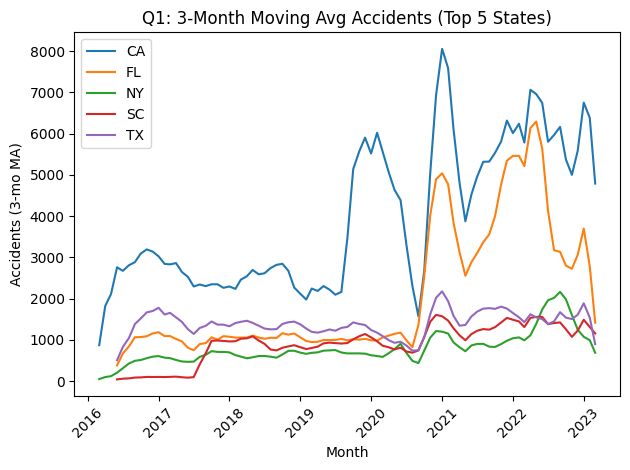

In [31]:
df1 = con.sql(q1).df()
df1["ym"] = pd.to_datetime(df1["Year"].astype(str) + "-" + df1["Month"].astype(str) + "-01")
top_states = df1.groupby("State")["accidents"].sum().sort_values(ascending=False).head(5).index.tolist()
df1 = df1[df1["State"].isin(top_states)]

plt.figure()
for st, g in df1.groupby("State"):
    g = g.sort_values("ym")
    plt.plot(g["ym"], g["ma_3mo"], label=st)
plt.title("Q1: 3-Month Moving Avg Accidents (Top 5 States)")
plt.xlabel("Month"); plt.ylabel("Accidents (3-mo MA)")
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [ ]:
# Additional Visualization: Overall Accident Trends by Year and Month
# This provides a simpler view of temporal trends across all states
q2_temporal = """
SELECT
  d.Year,
  d.Month,
  COUNT(*) AS accidents
FROM FACT_ACCIDENT f
JOIN DIM_DATE d ON d.Date_Key = f.Date_Key
GROUP BY d.Year, d.Month
ORDER BY d.Year, d.Month;
"""

df_temporal = con.sql(q2_temporal).df()
df_temporal["year_month"] = pd.to_datetime(
    df_temporal["Year"].astype(str) + "-" + df_temporal["Month"].astype(str) + "-01"
)

plt.figure(figsize=(12, 6))
plt.plot(df_temporal["year_month"], df_temporal["accidents"], marker='o', linewidth=2, markersize=4)
plt.title("Accident Trends by Year and Month (Overall)", fontsize=14, fontweight='bold')
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# ================================================================
# Q2) WEATHER DANGER RANKING – COMPOSITE RISK ANALYSIS
# ================================================================
# English Query (Business Question):
# Which weather conditions are the most dangerous? Rank combinations
# of (Condition, Visibility, Temp_Category) based on a composite
# danger score derived from accident severity and accident duration.
# Only include combinations with sufficient accident volume to
# ensure statistical reliability.
#
# SQL Logic:
# 1. Join FACT_ACCIDENT with DIM_WEATHER using Weather_Key.
# 2. Group by weather attributes (Condition, Visibility, Temp_Category).
# 3. Compute:
#    - Total accidents (volume threshold >= 200)
#    - Average Severity
#    - Average Duration (in minutes)
# 4. Calculate a composite danger_score:
#      (Avg Severity * 0.6) + (Avg Duration in hours * 0.4)
#    This weights severity more heavily while also considering
#    how long accidents disrupt traffic.
# 5. Rank results by danger_score (descending) and return top 20.
#
# Results & Interpretation:
# - Higher danger_score indicates more severe and longer-lasting accidents.
# - Volume filter (HAVING COUNT >= 200) prevents small-sample bias.
# - Helps identify high-risk weather patterns such as low visibility
#   combined with extreme temperature.
#
# Business Value:
# - Enables traffic authorities to prioritize alerts during
#   high-risk weather conditions.
# - Supports targeted safety campaigns (e.g., fog warnings).
# - Assists emergency services in resource allocation planning.
# - Can inform insurance risk modeling and policy adjustments.
#
# This query demonstrates multi-factor risk scoring, aggregation,
# filtering for statistical significance, and analytical ranking
# using star-schema design.
# ================================================================

In [33]:
# Q2) Weather danger ranking:
# Rank weather combinations (Condition, Visibility, Temp_Category) by a composite "danger score"
# based on average Severity and average Duration, and show top 20 (with enough volume).
q2 = """
SELECT
  w.Condition,
  w.Visibility,
  w.Temp_Category,
  COUNT(*) AS accidents,
  ROUND(AVG(f.Severity), 2) AS avg_severity,
  ROUND(AVG(f.Duration), 2) AS avg_duration_min,
  ROUND(
    (AVG(f.Severity) * 0.6) + (AVG(f.Duration) / 60.0 * 0.4)
  , 3) AS danger_score
FROM FACT_ACCIDENT f
JOIN DIM_WEATHER w ON w.Weather_Key = f.Weather_Key
GROUP BY 1,2,3
HAVING COUNT(*) >= 200
ORDER BY danger_score DESC, accidents DESC
LIMIT 20;
"""
df2 = con.sql(q2).df()
df2

,Condition,Visibility,Temp_Category,accidents,avg_severity,avg_duration_min,danger_score
0,N/A Precipitation,High,Cold,218,2.11,5000.69,34.604
1,Fair,Unknown,Hot,330,2.16,4926.13,34.139
2,Heavy T-Storm,Medium,Hot,293,2.15,3686.74,25.866
3,Thunder in the Vicinity,High,Mild,549,2.23,2973.80,21.162
4,T-Storm,High,Mild,864,2.24,2553.43,18.368
5,T-Storm,High,Hot,766,2.12,2165.75,15.713
6,Light Rain with Thunder,Medium,Hot,288,2.15,1915.80,14.064
7,Heavy T-Storm,Low,Mild,609,2.18,1836.80,13.552
8,Light Rain / Windy,Medium,Mild,346,2.19,1620.51,12.116
9,Thunder,High,Mild,365,2.18,1543.40,11.598


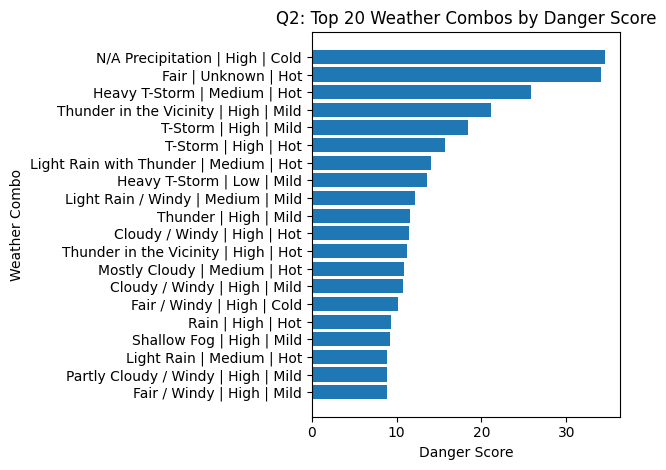

In [34]:
df2 = con.sql(q2).df()
df2["label"] = df2["Condition"] + " | " + df2["Visibility"] + " | " + df2["Temp_Category"]
plt.figure()
plt.barh(df2["label"][::-1], df2["danger_score"][::-1])
plt.title("Q2: Top 20 Weather Combos by Danger Score")
plt.xlabel("Danger Score"); plt.ylabel("Weather Combo")
plt.tight_layout(); plt.show()

In [35]:
# ================================================================
# Q3) TOP 3 ACCIDENT-PRONE CITIES PER STATE
# ================================================================
# English Query (Business Question):
# For each State, identify the top 3 cities with the highest
# number of accidents. This helps determine localized accident
# hotspots within each state.
#
# SQL Logic:
# 1. Join FACT_ACCIDENT with DIM_LOCATION using Location_Key.
# 2. Aggregate total accidents per (State, City).
# 3. Use ROW_NUMBER() window function partitioned by State
#    and ordered by accident count (descending) to rank cities.
# 4. Filter to keep only the top 3 cities per state (rn <= 3).
# 5. Order results by State and accident count for readability.
#
# Results & Interpretation:
# - Returns the 3 highest-accident cities in each state.
# - Highlights concentrated accident zones rather than
#   distributing risk uniformly across the state.
# - Useful for identifying urban congestion patterns.
#
# Business Value:
# - Enables targeted infrastructure improvements in high-risk cities.
# - Supports local law enforcement deployment planning.
# - Helps state transportation departments prioritize funding.
# - Assists urban planners in redesigning accident-prone areas.
#
# This query demonstrates partition-based ranking using
# window functions and geographic OLAP analysis within
# the star-schema data warehouse.
# ================================================================

In [37]:
q3 = """
WITH city_counts AS (
  SELECT
    l.State,
    l.City,
    COUNT(*) AS accidents
  FROM FACT_ACCIDENT f
  JOIN DIM_LOCATION l ON l.Location_Key = f.Location_Key
  GROUP BY 1,2
),
ranked AS (
  SELECT
    *,
    ROW_NUMBER() OVER (PARTITION BY State ORDER BY accidents DESC) AS rn
  FROM city_counts
)
SELECT State, City, accidents
FROM ranked
WHERE rn <= 3
ORDER BY State, accidents DESC;
"""
df3 = con.sql(q3).df()
df3.head(50)

,State,City,accidents
0,AL,Birmingham,3221
1,AL,Montgomery,1994
2,AL,Huntsville,1545
3,AR,Little Rock,860
4,AR,North Little Rock,314
5,AR,Benton,150
6,AZ,Phoenix,10493
7,AZ,Tucson,7721
8,AZ,Tempe,1847
9,CA,Los Angeles,30326


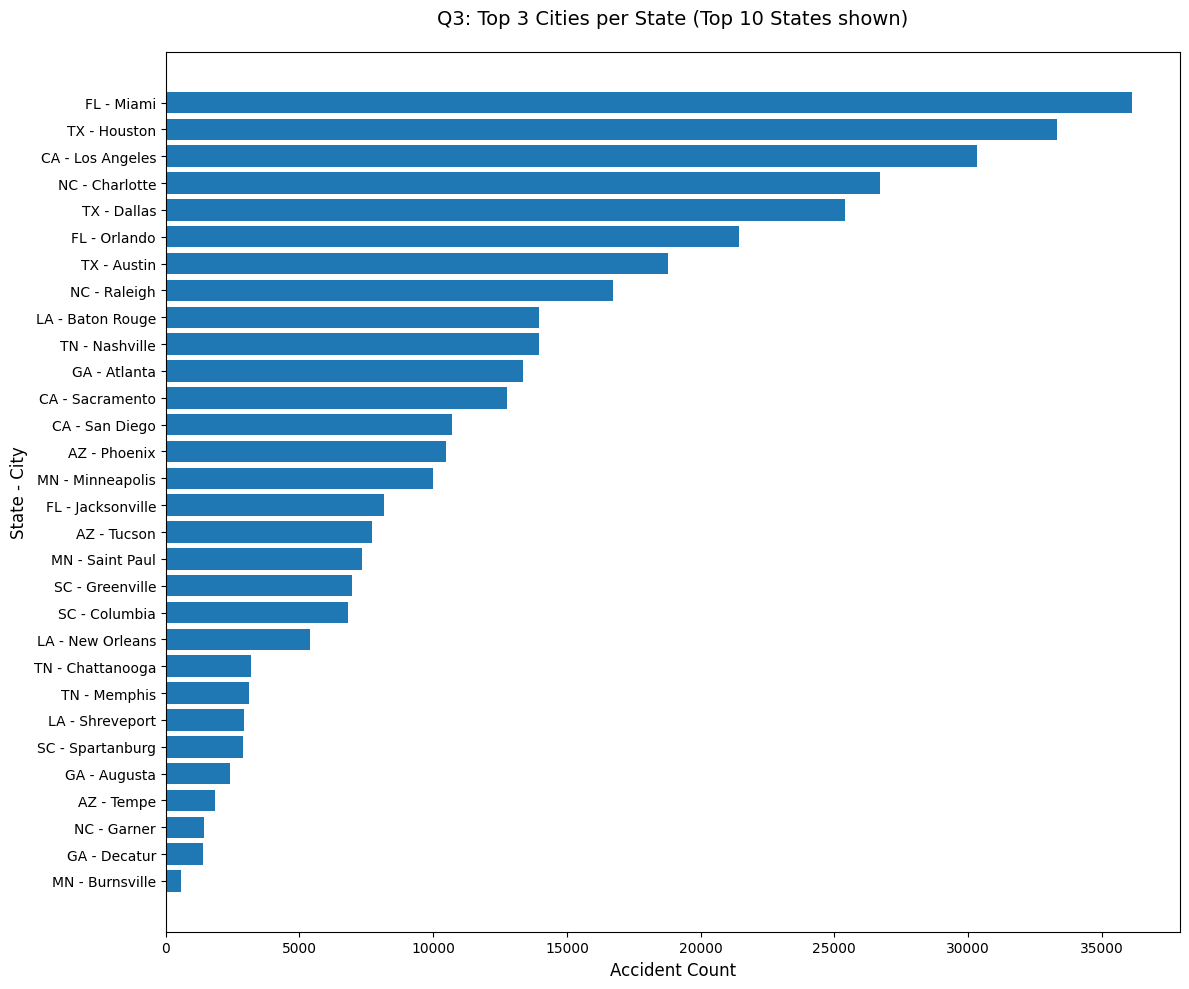

In [38]:
# Better approach - either show top 3 cities overall OR group by state more clearly
df3 = con.sql(q3).df()
top_states_q3 = df3.groupby("State")["accidents"].sum().sort_values(ascending=False).head(10).index.tolist()
df3 = df3[df3["State"].isin(top_states_q3)]
df3["state_city"] = df3["State"] + " - " + df3["City"]
tmp = df3.sort_values("accidents", ascending=True)  # Sort by count for better visualization

plt.figure(figsize=(12, 10))  # Increase figure size
plt.barh(tmp["state_city"], tmp["accidents"])
plt.title("Q3: Top 3 Cities per State (Top 10 States shown)", fontsize=14, pad=20)
plt.xlabel("Accident Count", fontsize=12)
plt.ylabel("State - City", fontsize=12)
plt.tight_layout()
plt.show()


In [73]:
# ================================================================
# Q4) PARETO ANALYSIS – ACCIDENT CONCENTRATION BY CITY
# ================================================================
# English Query (Business Question):
# Within each State, determine how accident counts are concentrated
# across cities and identify how many cities contribute to approximately
# 80% of total accidents (Pareto principle analysis).
#
# SQL Logic:
# 1. Aggregate accident counts per (State, City).
# 2. Compute total accidents per State.
# 3. Use a cumulative SUM() window function partitioned by State
#    and ordered by accidents (descending) to calculate running totals.
# 4. Compute cumulative percentage contribution:
#       (cumulative accidents / total state accidents) * 100.
# 5. Order results to show highest contributing cities first.
#
# Results & Interpretation:
# - Displays cumulative accident percentage (cum_pct) per city.
# - Helps determine if a small number of cities account for
#   the majority (~80%) of accidents.
# - Identifies high-impact cities within each state.
#
# Business Value:
# - Supports targeted safety investment where impact is highest.
# - Enables efficient allocation of traffic enforcement resources.
# - Helps policymakers apply Pareto-based prioritization.
# - Improves cost-effectiveness of road safety interventions.
#
# This query demonstrates cumulative window functions,
# percentage contribution analysis, and concentration-based
# OLAP insights using the star-schema design.
# ================================================================

In [39]:
# Q4) Pareto / concentration analysis:
# Within each State, compute cumulative accident contribution by City (descending),
# to see how many cities account for ~80% of accidents.
q4 = """
WITH city_counts AS (
  SELECT
    l.State,
    l.City,
    COUNT(*) AS accidents
  FROM FACT_ACCIDENT f
  JOIN DIM_LOCATION l ON l.Location_Key = f.Location_Key
  GROUP BY 1,2
),
state_totals AS (
  SELECT State, SUM(accidents) AS state_total
  FROM city_counts
  GROUP BY 1
),
ranked AS (
  SELECT
    c.State,
    c.City,
    c.accidents,
    t.state_total,
    SUM(c.accidents) OVER (
      PARTITION BY c.State
      ORDER BY c.accidents DESC
      ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cum_accidents
  FROM city_counts c
  JOIN state_totals t USING (State)
)
SELECT
  State,
  City,
  accidents,
  state_total,
  ROUND(100.0 * cum_accidents / NULLIF(state_total,0), 2) AS cum_pct
FROM ranked
ORDER BY State, accidents DESC;
"""
df4 = con.sql(q4).df()
df4.head(50)

,State,City,accidents,state_total,cum_pct
0,AL,Birmingham,3221,19386.0,16.62
1,AL,Montgomery,1994,19386.0,26.90
2,AL,Huntsville,1545,19386.0,34.87
3,AL,Tuscaloosa,1354,19386.0,41.85
4,AL,Mobile,1348,19386.0,48.81
5,AL,Madison,466,19386.0,51.21
6,AL,Northport,388,19386.0,53.21
7,AL,Dothan,374,19386.0,55.14
8,AL,Clanton,354,19386.0,56.97
9,AL,Daphne,311,19386.0,58.57


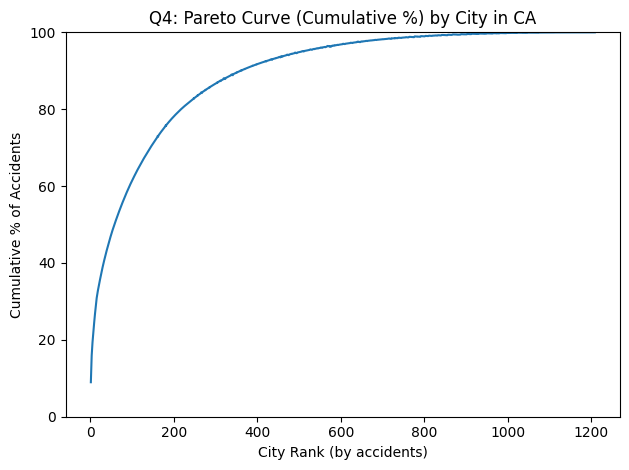

In [40]:
df4 = con.sql(q4).df()
top_state = df4.groupby("State")["accidents"].sum().sort_values(ascending=False).index[0]
g = df4[df4["State"] == top_state].sort_values("accidents", ascending=False).reset_index(drop=True)
g["city_rank"] = g.index + 1
plt.figure()
plt.plot(g["city_rank"], g["cum_pct"])
plt.title(f"Q4: Pareto Curve (Cumulative %) by City in {top_state}")
plt.xlabel("City Rank (by accidents)"); plt.ylabel("Cumulative % of Accidents")
plt.ylim(0, 100); plt.tight_layout(); plt.show()

In [41]:
# ================================================================
# Q5) INTERACTION EFFECT ANALYSIS – TimeOfDay × Visibility
# ================================================================
# English Query (Business Question):
# How do accident patterns change when combining TimeOfDay and
# Visibility conditions? Identify which combinations lead to:
# - Higher accident counts
# - Higher average severity
# - Higher percentage of severe accidents (Severity 3–4)
#
# SQL Logic:
# 1. Join FACT_ACCIDENT with DIM_TIME and DIM_WEATHER.
# 2. Group by TimeOfDay and Visibility levels.
# 3. Compute:
#    - Total accident count
#    - Average severity
#    - Percentage of severe accidents (Severity 3 or 4)
#      using conditional aggregation.
# 4. Apply HAVING COUNT(*) >= 300 to ensure statistical significance.
# 5. Order results by highest severe percentage and average severity.
#
# Results & Interpretation:
# - Identifies risky combinations such as Night + Low Visibility.
# - Highlights interaction effects rather than analyzing
#   time and weather independently.
# - Higher pct_severe_3_4 indicates more dangerous conditions.
#
# Business Value:
# - Enables targeted safety warnings during high-risk time-weather conditions.
# - Helps traffic departments deploy patrol units strategically.
# - Supports dynamic road signage and public awareness campaigns.
# - Assists insurance companies in understanding contextual risk factors.
#
# This query demonstrates multi-dimensional interaction analysis,
# conditional aggregation, statistical filtering, and OLAP-based
# decision support within the star-schema warehouse.
# ================================================================

In [42]:
# Q5) Interaction effect (TimeOfDay × Visibility):
# Compare accident counts, average severity, and % severe (Severity 3–4)
# across TimeOfDay buckets and Visibility levels to identify risky combinations.
q5 = """
SELECT
  t.TimeOfDay,
  w.Visibility,
  COUNT(*) AS accidents,
  ROUND(AVG(f.Severity), 2) AS avg_severity,
  ROUND(100.0 * AVG(CASE WHEN f.Severity IN (3,4) THEN 1 ELSE 0 END), 2) AS pct_severe_3_4
FROM FACT_ACCIDENT f
JOIN DIM_TIME t ON t.Time_Key = f.Time_Key
JOIN DIM_WEATHER w ON w.Weather_Key = f.Weather_Key
GROUP BY 1,2
HAVING COUNT(*) >= 300
ORDER BY pct_severe_3_4 DESC, avg_severity DESC;
"""
df5 = con.sql(q5).df()
df5

,TimeOfDay,Visibility,accidents,avg_severity,pct_severe_3_4
0,Morning,Unknown,11441,2.26,23.21
1,Evening,Unknown,5256,2.26,22.68
2,Afternoon,Unknown,9626,2.25,21.73
3,Afternoon,Medium,22550,2.24,21.62
4,Morning,Medium,44139,2.23,21.53
5,Evening,Medium,12408,2.23,21.38
6,Evening,Low,4851,2.25,21.36
7,Afternoon,Low,9940,2.24,20.73
8,Evening,High,230600,2.22,20.67
9,Night,Medium,21892,2.24,19.77


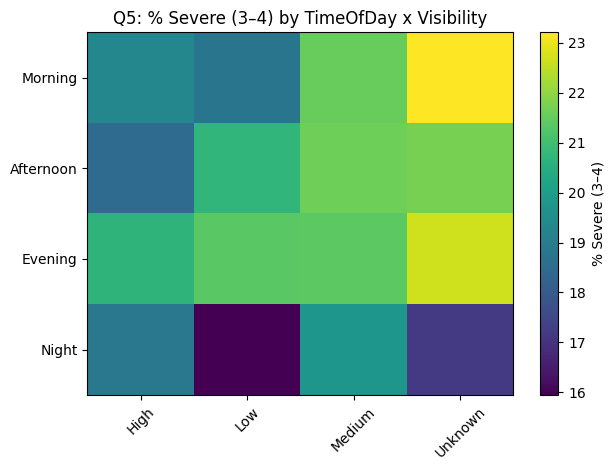

In [43]:
df5 = con.sql(q5).df()
pivot5 = df5.pivot(index="TimeOfDay", columns="Visibility", values="pct_severe_3_4")
pivot5 = pivot5.reindex(index=[x for x in ["Morning","Afternoon","Evening","Night"] if x in pivot5.index])
plt.figure()
plt.imshow(pivot5.values, aspect="auto")
plt.title("Q5: % Severe (3–4) by TimeOfDay x Visibility")
plt.xticks(range(len(pivot5.columns)), pivot5.columns, rotation=45)
plt.yticks(range(len(pivot5.index)), pivot5.index)
plt.colorbar(label="% Severe (3–4)")
plt.tight_layout(); plt.show()


In [44]:
# ================================================================
# Q6) OUTLIER DETECTION – CITY SEVERITY Z-SCORE ANALYSIS
# ================================================================
# English Query (Business Question):
# Which cities have unusually high accident severity compared to
# their respective state baseline? Identify statistically significant
# outlier cities using a z-score approach (with sufficient sample size).
#
# SQL Logic:
# 1. Compute city-level statistics:
#    - Total accident count (n)
#    - Average accident severity per city
#    - Include only cities with sufficient volume (n >= 200)
#      to ensure statistical reliability.
# 2. Compute state-level statistics based on city averages:
#    - Mean of city average severity
#    - Standard deviation (STDDEV_SAMP) of city averages
# 3. Calculate z-score:
#       (City Avg Severity − State Mean) / State Std Dev
#    A higher positive z-score indicates the city’s severity
#    is significantly above the state baseline.
# 4. Rank cities by z-score (descending) and return top 25.
#
# Results & Interpretation:
# - z_score > 0 → Above state average severity.
# - Large positive z_score (e.g., > 2) → Potential statistical outlier.
# - Identifies cities with disproportionately severe accidents
#   rather than simply high accident volume.
#
# Business Value:
# - Helps transportation authorities focus on severity hotspots.
# - Supports targeted road safety interventions in extreme-risk cities.
# - Assists policymakers in identifying structural safety issues.
# - Provides data-driven prioritization for safety audits and funding.
#
# This query demonstrates statistical analysis (mean, standard deviation,
# z-score), multi-level aggregation, sample-size filtering, and advanced
# OLAP analytics within the star-schema data warehouse.
# ================================================================

In [45]:
# Q6) Outlier detection:
# Identify Cities whose average Severity is unusually high compared to their State baseline
# using a z-score (cities with enough sample size only).
q6 = """
WITH city_stats AS (
  SELECT
    l.State,
    l.City,
    COUNT(*) AS n,
    AVG(f.Severity) AS city_avg_sev
  FROM FACT_ACCIDENT f
  JOIN DIM_LOCATION l ON l.Location_Key = f.Location_Key
  GROUP BY 1,2
  HAVING COUNT(*) >= 200
),
state_stats AS (
  SELECT
    State,
    AVG(city_avg_sev) AS state_mean,
    STDDEV_SAMP(city_avg_sev) AS state_std
  FROM city_stats
  GROUP BY 1
)
SELECT
  c.State,
  c.City,
  c.n,
  ROUND(c.city_avg_sev, 3) AS city_avg_severity,
  ROUND(s.state_mean, 3) AS state_mean_severity,
  ROUND((c.city_avg_sev - s.state_mean) / NULLIF(s.state_std,0), 3) AS z_score
FROM city_stats c
JOIN state_stats s USING (State)
WHERE s.state_std IS NOT NULL
ORDER BY z_score DESC
LIMIT 25;
"""
df6 = con.sql(q6).df()
df6

,State,City,n,city_avg_severity,state_mean_severity,z_score
0,IL,Joliet,200,2.730,2.223,2.953
1,CA,Visalia,921,2.540,2.152,2.842
2,SC,Bowman,332,2.410,2.112,2.499
3,IL,Hillside,236,2.648,2.223,2.477
4,FL,Deerfield Beach,437,2.487,2.153,2.461
5,PA,Bensalem,237,2.443,2.127,2.418
6,OR,Springfield,243,2.230,2.101,2.376
7,PA,Harrisburg,853,2.436,2.127,2.365
8,PA,Chester,277,2.430,2.127,2.315
9,SC,North Charleston,1003,2.384,2.112,2.283


In [ ]:
# Additional Visualization: Stacked Bar Chart by Year and TimeOfDay (Excluding Unknown)
# Helper functions to aggregate data by different dimensions
def year_time_level(df):
    # (Year, TimeOfDay) level only; State and Condition rolled up
    return df[(df["Year"].notna()) & (df["TimeOfDay"].notna()) & (df["State"].isna()) & (df["Condition"].isna())]

def state_level(df):
    # (State) only; all other dims rolled up
    return df[(df["Year"].isna()) & (df["TimeOfDay"].isna()) & (df["State"].notna()) & (df["Condition"].isna())]

def condition_level(df):
    # (Condition) only; all other dims rolled up
    return df[(df["Year"].isna()) & (df["TimeOfDay"].isna()) & (df["State"].isna()) & (df["Condition"].notna())]

df_yt = year_time_level(df7)

# Filter out "Unknown" TimeOfDay values
df_yt = df_yt[df_yt["TimeOfDay"] != "Unknown"]

# Create pivot table for stacked bar chart
pivot = df_yt.pivot_table(
    index="Year", columns="TimeOfDay", values="accidents", aggfunc="sum", fill_value=0
)

# Define the order of TimeOfDay categories (excluding Unknown)
order = [c for c in ["Morning", "Afternoon", "Evening", "Night"] if c in pivot.columns]
pivot = pivot.reindex(columns=order)

# Create stacked bar chart
ax = pivot.plot(kind="bar", stacked=True)
ax.set_title("Accident Counts by TimeOfDay per Year (Stacked)")
ax.set_xlabel("Year")
ax.set_ylabel("Accidents")
plt.tight_layout()
plt.show()

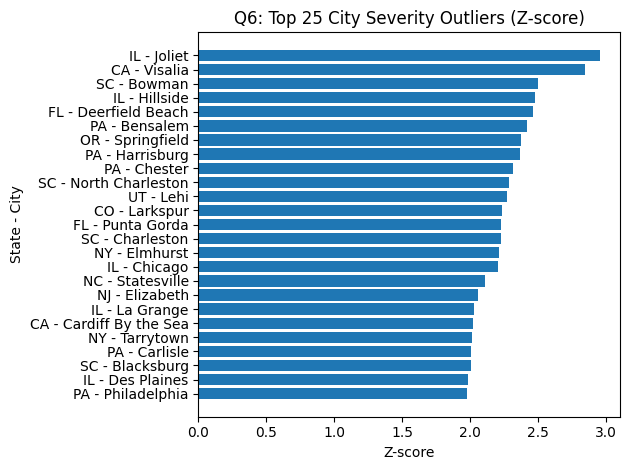

In [46]:
df6 = con.sql(q6).df()
df6["label"] = df6["State"] + " - " + df6["City"]
plt.figure()
plt.barh(df6["label"][::-1], df6["z_score"][::-1])
plt.title("Q6: Top 25 City Severity Outliers (Z-score)")
plt.xlabel("Z-score"); plt.ylabel("State - City")
plt.tight_layout(); plt.show()

In [47]:
# ================================================================
# Q7) OLAP CUBE ANALYSIS – MULTI-DIMENSIONAL ACCIDENT SUMMARY
# ================================================================
# English Query (Business Question):
# Build a multi-dimensional analytical cube to summarize accident
# counts and average severity across:
#   (Year, TimeOfDay, State, Weather Condition).
# Include subtotal and grand total aggregations to support
# hierarchical roll-up and drill-down analysis.
#
# SQL Logic:
# 1. Join FACT_ACCIDENT with DIM_DATE, DIM_TIME,
#    DIM_LOCATION, and DIM_WEATHER.
# 2. Aggregate:
#    - Total accident count
#    - Average severity
# 3. Use GROUP BY CUBE to automatically generate:
#    - All dimension combinations
#    - Subtotals for each dimension
#    - Grand total across all dimensions
# 4. ORDER BY with NULLS LAST ensures subtotal rows
#    appear after detailed rows for clarity.
#
# Results & Interpretation:
# - Rows with NULL values represent subtotal aggregations.
# - Enables comparison across multiple dimensions simultaneously.
# - Supports drill-down (e.g., Year → State → TimeOfDay).
# - Provides a complete analytical view of accident patterns.
#
# Business Value:
# - Supports executive-level dashboard reporting.
# - Enables flexible slicing/dicing across dimensions.
# - Assists in strategic planning and policy evaluation.
# - Improves multi-factor risk assessment and forecasting.
#
# This query demonstrates advanced OLAP functionality using
# CUBE, hierarchical aggregation, star-schema joins,
# and multi-dimensional analytical modeling.
# ================================================================

In [48]:
# Q7) OLAP Cube summary:
# Build a multi-dimensional cube of accident counts and average severity across
# (Year, TimeOfDay, State, Weather Condition), including subtotals for rollups.
q7 = """
SELECT
  d.Year,
  t.TimeOfDay,
  l.State,
  w.Condition,
  COUNT(*) AS accidents,
  ROUND(AVG(f.Severity), 2) AS avg_severity
FROM FACT_ACCIDENT f
JOIN DIM_DATE d ON d.Date_Key = f.Date_Key
JOIN DIM_TIME t ON t.Time_Key = f.Time_Key
JOIN DIM_LOCATION l ON l.Location_Key = f.Location_Key
JOIN DIM_WEATHER w ON w.Weather_Key = f.Weather_Key
GROUP BY CUBE (d.Year, t.TimeOfDay, l.State, w.Condition)
ORDER BY d.Year NULLS LAST, t.TimeOfDay NULLS LAST, l.State NULLS LAST, w.Condition NULLS LAST;
"""
df7 = con.sql(q7).df()
df7.head(50)

,Year,TimeOfDay,State,Condition,accidents,avg_severity
0,2016,Afternoon,AL,Clear,3,2.33
1,2016,Afternoon,AL,Light Rain,1,2.00
2,2016,Afternoon,AL,Mostly Cloudy,2,4.00
3,2016,Afternoon,AL,Partly Cloudy,2,2.00
4,2016,Afternoon,AL,Scattered Clouds,1,2.00
5,2016,Afternoon,AL,None,9,2.56
6,2016,Afternoon,AR,Clear,2,3.50
7,2016,Afternoon,AR,None,2,3.50
8,2016,Afternoon,AZ,Clear,55,2.60
9,2016,Afternoon,AZ,Haze,1,2.00


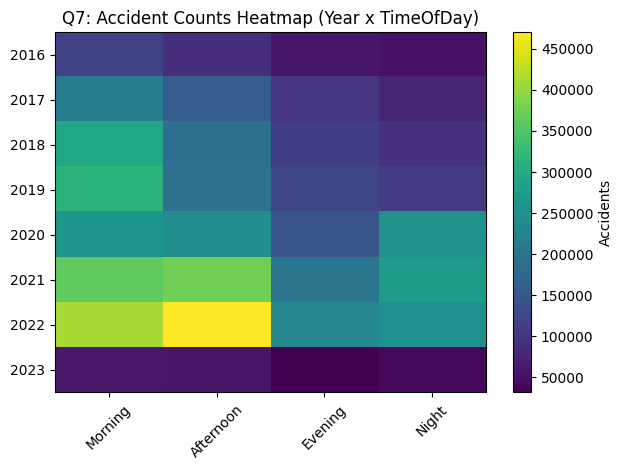

In [49]:
df7 = con.sql(q7).df()

# If duplicates exist, pivot_table will aggregate them safely
pivot7 = df7.pivot_table(
    index="Year",
    columns="TimeOfDay",
    values="accidents",
    aggfunc="sum",      # or "mean"
    fill_value=0
)

# Keep nice column order (only those that exist)
pivot7 = pivot7.reindex(columns=[c for c in ["Morning","Afternoon","Evening","Night"] if c in pivot7.columns])

plt.figure()
plt.imshow(pivot7.values, aspect="auto")
plt.title("Q7: Accident Counts Heatmap (Year x TimeOfDay)")
plt.xticks(range(len(pivot7.columns)), pivot7.columns, rotation=45)
plt.yticks(range(len(pivot7.index)), pivot7.index)
plt.colorbar(label="Accidents")
plt.tight_layout()
plt.show()

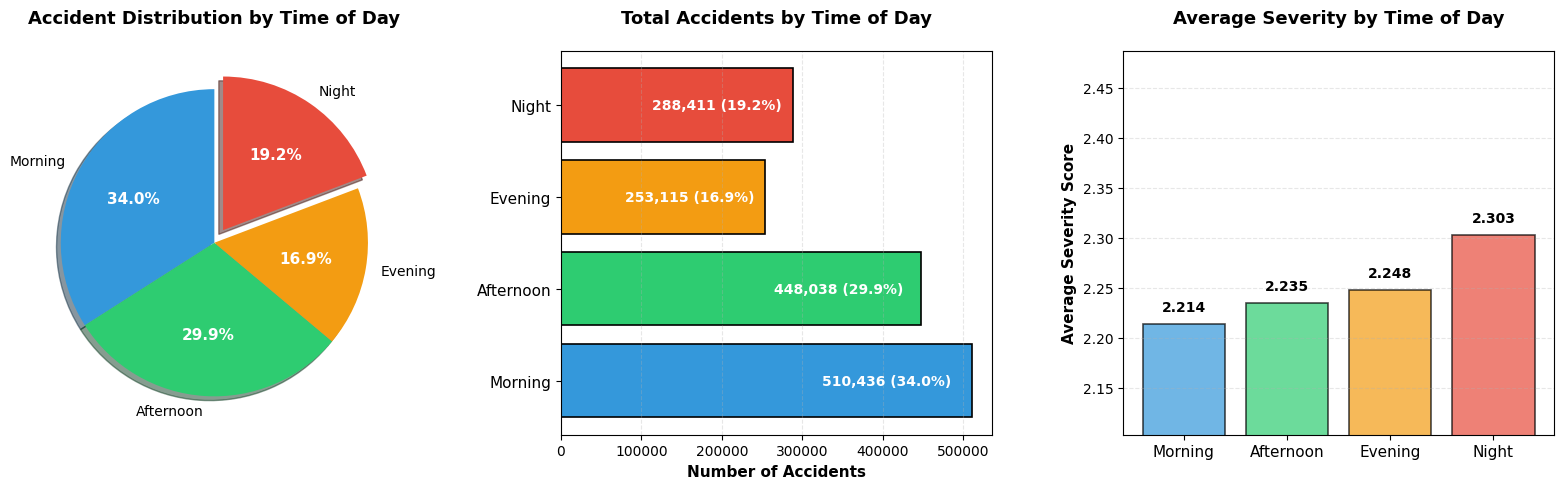


ACCIDENT TRENDS BY TIME OF DAY OVER YEARS


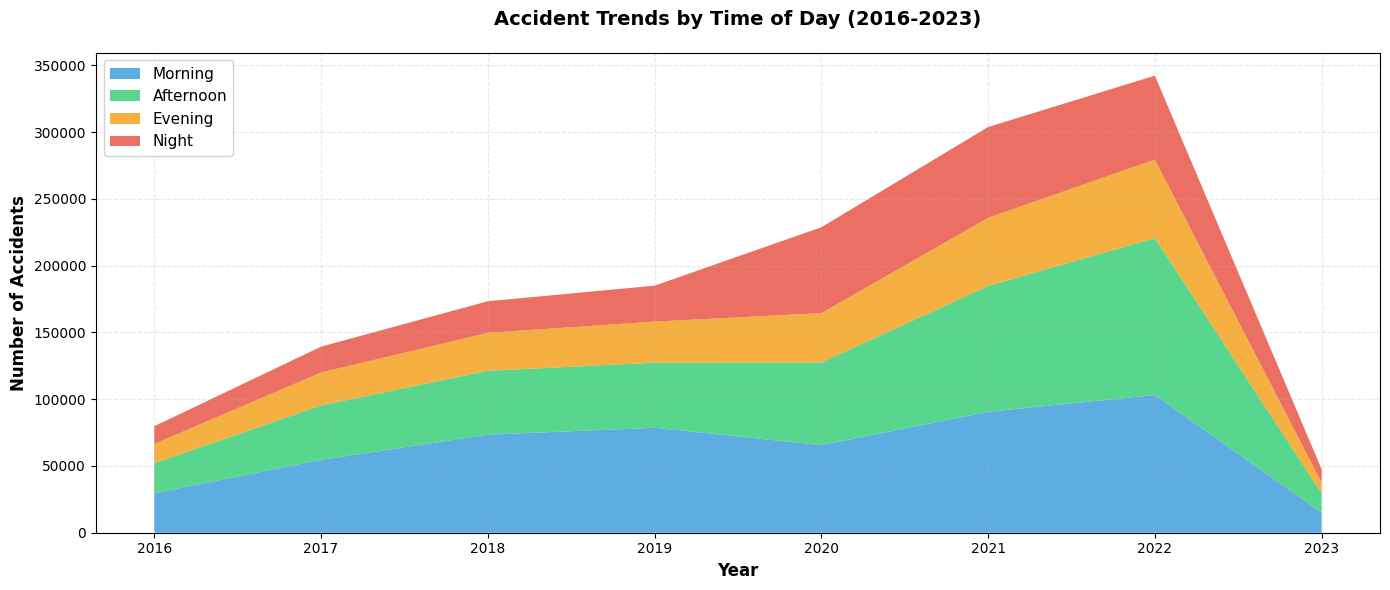


Summary Statistics:
----------------------------------------------------------------------
Morning     :    510,436 accidents ( 34.0%) | Avg Severity: 2.214
Afternoon   :    448,038 accidents ( 29.9%) | Avg Severity: 2.235
Evening     :    253,115 accidents ( 16.9%) | Avg Severity: 2.248
Night       :    288,411 accidents ( 19.2%) | Avg Severity: 2.303


In [54]:
# Better visualizations for TimeOfDay analysis
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
time_distribution = df_yt.groupby('TimeOfDay')['accidents'].sum()
total_accidents = time_distribution.sum()
severity_by_time = df_yt.groupby('TimeOfDay')['avg_severity'].mean()

# Define order and colors
time_order = ["Morning", "Afternoon", "Evening", "Night"]
time_distribution = time_distribution.reindex(time_order)
severity_by_time = severity_by_time.reindex(time_order)

# Color scheme - highlight Night
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']  # Blue, Green, Orange, Red

# Create figure with 3 subplots
fig = plt.figure(figsize=(16, 5))

# 1. Pie chart for distribution
ax1 = plt.subplot(1, 3, 1)
explode = (0, 0, 0, 0.1)  # Explode the Night slice
wedges, texts, autotexts = ax1.pie(
    time_distribution, 
    labels=time_order,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True
)
# Make percentage text bold and larger
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
ax1.set_title('Accident Distribution by Time of Day', fontsize=13, fontweight='bold', pad=20)

# 2. Horizontal bar chart for total counts
ax2 = plt.subplot(1, 3, 2)
y_pos = np.arange(len(time_order))
bars = ax2.barh(y_pos, time_distribution.values, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars - INSIDE the bars for better fit
for i, (bar, count) in enumerate(zip(bars, time_distribution.values)):
    percentage = (count / total_accidents) * 100
    # Place text inside the bar, aligned to the right
    ax2.text(count * 0.95, i, 
             f'{count:,} ({percentage:.1f}%)', 
             va='center', ha='right', fontweight='bold', fontsize=10, color='white')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(time_order, fontsize=11)
ax2.set_xlabel('Number of Accidents', fontsize=11, fontweight='bold')
ax2.set_title('Total Accidents by Time of Day', fontsize=13, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
# Add some padding to the right side
ax2.set_xlim(right=max(time_distribution) * 1.05)

# 3. Severity comparison
ax3 = plt.subplot(1, 3, 3)
x_pos = np.arange(len(time_order))

# Bar chart for severity
bars = ax3.bar(x_pos, severity_by_time.values, color=colors, alpha=0.7, 
               edgecolor='black', linewidth=1.2, label='Avg Severity')

# Add value labels on bars
for i, (bar, severity) in enumerate(zip(bars, severity_by_time.values)):
    ax3.text(i, severity + 0.01, f'{severity:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(time_order, fontsize=11)
ax3.set_ylabel('Average Severity Score', fontsize=11, fontweight='bold')
ax3.set_title('Average Severity by Time of Day', fontsize=13, fontweight='bold', pad=20)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_ylim(bottom=severity_by_time.min() * 0.95, top=severity_by_time.max() * 1.08)

plt.tight_layout()
plt.show()

# Additional: Stacked area chart showing trend over years
print("\n" + "=" * 70)
print("ACCIDENT TRENDS BY TIME OF DAY OVER YEARS")
print("=" * 70)

# Pivot for trend analysis
trend_pivot = df_yt.pivot_table(
    index='Year', 
    columns='TimeOfDay', 
    values='accidents', 
    aggfunc='sum', 
    fill_value=0
).reindex(columns=time_order)

# Create stacked area chart
fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(trend_pivot.index, 
             trend_pivot['Morning'], 
             trend_pivot['Afternoon'],
             trend_pivot['Evening'],
             trend_pivot['Night'],
             labels=time_order,
             colors=colors,
             alpha=0.8)

ax.set_title('Accident Trends by Time of Day (2016-2023)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Accidents', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("-" * 70)
for time_period in time_order:
    count = time_distribution[time_period]
    percentage = (count / total_accidents) * 100
    severity = severity_by_time[time_period]
    print(f"{time_period:12s}: {count:>10,} accidents ({percentage:>5.1f}%) | Avg Severity: {severity:.3f}")